# EDA — Dispensas de Farmacia (Obra Social)
Trabajo Final — Introducción al Aprendizaje de Máquinas
Rodriguez Nelson / Benitez Mirna

Este notebook realiza el análisis exploratorio del dataset de dispensas de farmacia,
previo al feature engineering y entrenamiento del Autoencoder.

## Ofuscación de datos
Para proteger la privacidad al compartir el dataset, es crucial ofuscar cualquier dato sensible. Esto implica transformar los identificadores únicos en otros que no puedan vincularse a la información original, pero que sigan permitiendo el análisis dentro del dataset.

Utilizamos una función de hash SHA-256 para `CUF`, `Nro.Afil` y `Afiliado`. Creamos un nuevo DataFrame `df_PUBLICO_combined_total.csv` con estos datos ofuscados y eliminamos las columnas originales.

## 1. Carga de datos
Subir el CSV a Drive y montar, o subirlo directo a la sesión de Colab.

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:


# Ruta al CSV del Drive
RUTA_DATASET = '/content/drive/My Drive/DOCTORADO 2026/Introduccion al aprendizaje de Maquinas/Dataset/Activo_Pasivo/Salida/df_PUBLICO_combined_total.csv'
# RUTA_SALIDA directorio para los resultados
RUTA_SALIDA_DIR = '/content/drive/My Drive/DOCTORADO 2026/Introduccion al aprendizaje de Maquinas/Dataset/Activo_Pasivo/Salida/'

import os
os.makedirs(RUTA_SALIDA_DIR, exist_ok=True)


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv(RUTA_DATASET, parse_dates=['F. Receta', 'F.Validac.'])
print(df.shape)
df.head()


/tmp/ipykernel_2256/779052840.py:9: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RUTA_DATASET, parse_dates=['F. Receta', 'F.Validac.'])


(512396, 40)


,CUIT,Razon Social,Nombre Fantasia,calle_nombre,calle_altura,localidad_nombre,Provincia,F.Validac.,Nro. Receta,Nro.item,sexo,Edad (años),Producto,Cantidad,P.Venta,Desc.,Cod.Valid.,Estado,F. Receta,p.Activo,Cobertura,Plan,T.mat,nro.mat.,medico,registroab,troquel,codigobarra,nrodoc,Ctro Costo,Laboratorio,Labo_Id,Prestador,Presentacion fcia,ID externo,Recetario Orig,semana,CUF_hashed,Nro.Afil_hashed,Afiliado_hashed
0,30687986993,FARMACIA DEL PUENTE SCS,DEL PUENTE,AVENIDA JUAN RAMON VIDAL,1609,CORRIENTES,CORRIENTES,2026-04-01 00:04:28.559095,2609063541081,1,F,55.0,CALCIO BASE DUPOMAR comp.x 60,1,20815.87,10407.94,2609149911756,Receta Presentada en un lote por la farmacia,2026-03-31,"calcio,carbonato",50.0,1139,MPW,5052.0,GIMENEZ CLAUDIO ROBERTO,7847,3129422,7.798129e+12,17813121,NaN,Siegfried,903,NaN,105239003395358682,0,2609063541081,2026-03-30,cf5da9fd80b6af3c56cb69005df18513c274f5c3fe5886...,b8d7c6664c7c9473b145b73290266c28e27525c2cadc9e...,285ba0bad75afbe7729bab3d6425eb7c3cf5dfeb4eb279...
1,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-04-01 01:11:38.540070,2608963461507,1,F,55.0,INQUETIA 25 mg comp.x 30,1,57199.00,28599.50,2609149911890,Receta Presentada en un lote por la farmacia,2026-03-30,quetiapina,50.0,1139,MPW,5920.0,ROMERO VALDEZ Jorge Gustavo,45579,5945842,7.795345e+12,39519642,NaN,Roemmers,203,NaN,105239003145353745,0,2608963461507,2026-03-30,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,eadd229ee85d59747c7ca78b9ea561fc2975391e3c2b26...,99f9bd6477af2eaf04e252abe70c382d04369321a88f31...
2,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-04-01 01:11:58.236343,2608963461608,1,F,55.0,VALCOTE 250 mg comp.x 50,1,78554.23,39277.12,2609149911892,Receta Presentada en un lote por la farmacia,2026-03-30,"sodio,divalproato",50.0,1139,MPW,5920.0,ROMERO VALDEZ Jorge Gustavo,8518,3061014,7.790441e+12,39519642,NaN,Abbott EPD,829,NaN,105239003145353745,0,2608963461608,2026-03-30,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,eadd229ee85d59747c7ca78b9ea561fc2975391e3c2b26...,99f9bd6477af2eaf04e252abe70c382d04369321a88f31...
3,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-04-01 01:40:23.505754,2608963467803,1,M,55.0,CLONAGIN gts.x 20 ml,1,14297.40,7148.70,2609149911926,Receta Presentada en un lote por la farmacia,2026-03-30,clonazepam,50.0,1139,MPW,4816.0,SERRACANI GRISELDA SOLEDAD,30537,4423012,7.795338e+12,23397639,NaN,Baliarda,23,NaN,105239003145353745,0,2608963467803,2026-03-30,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,d0a7b3a70eb84900573e7d1fb6f220f2f3f28f7f3e1632...,f741e8364bc0f82d7acfbab2bfab5eb4f227f400692d6b...
4,30643249312,FARMACIA 3 DE ABRIL SCS,3 DE ABRIL,MENDOZA,1598,CORRIENTES,CORRIENTES,2026-04-01 01:48:20.401973,2609063619861,1,F,55.0,ROSUVAST 20 20 mg comp.x 30,1,46522.63,23261.32,2609149911929,Receta Presentada en un lote por la farmacia,2026-03-31,rosuvastatina,50.0,1139,MPW,765.0,ARGIEL ANIBAL,59520,5208313,7.790375e+12,18499336,NaN,Bagó,21,NaN,105239003225361740,0,2609063619861,2026-03-30,d769a280d3975662acfda60b3627eeced74d03f515aa5c...,00ad7539535be3644ab21dd056716bbaf1e1e838f3504b...,3a960c2b0d843e342ed5dcbe1266ba7730e292b2b939a1...


## 2. Estructura general y tipos de datos

In [52]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512396 entries, 0 to 512395
Data columns (total 40 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CUIT               512396 non-null  int64         
 1   Razon Social       512396 non-null  object        
 2   Nombre Fantasia    512396 non-null  object        
 3   calle_nombre       512396 non-null  object        
 4   calle_altura       512396 non-null  int64         
 5   localidad_nombre   512396 non-null  object        
 6   Provincia          512396 non-null  object        
 7   F.Validac.         512396 non-null  datetime64[ns]
 8   Nro. Receta        512396 non-null  object        
 9   Nro.item           512396 non-null  int64         
 10  sexo               512396 non-null  object        
 11  Edad (años)        512396 non-null  float64       
 12  Producto           512396 non-null  object        
 13  Cantidad           512396 non-null  int64   

## 3. Valores nulos por columna

Ctro Costo     512396
Prestador      512391
T.mat               8
nro.mat.            8
medico              8
codigobarra         6
dtype: int64


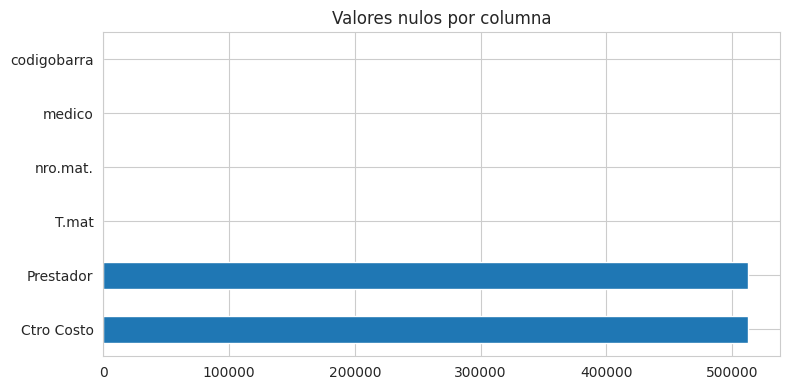

In [53]:
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
print(nulos)

if len(nulos) > 0:
    plt.figure(figsize=(8,4))
    nulos.plot(kind='barh')
    plt.title('Valores nulos por columna')
    plt.tight_layout()
    plt.show()


Existen dos columnas (Prestador, Ctro Costo) que no aportan valor al entrenamento del modelo ya que estas en su gran mayoria contienen solo valores nulos, como asi tambien un grupo de registros que no contienen valores en los campos T.mat, nro.mat., medico y codigobarra, por lo cual seran eliminadas del dataset.

## 4. Duplicados

In [54]:
print('Filas duplicadas exactas:', df.duplicated().sum())
print('Cod.Valid. duplicados:', df['Cod.Valid.'].duplicated().sum())


Filas duplicadas exactas: 0
Cod.Valid. duplicados: 125244


Existen códigos de validaciones duplicados por que cada registro representa un medicamento dispensado y varios medicamentos pueden estar indicados juntos en una misma receta por lo que tienen el mismo código de validación.

## 5. Distribución demográfica (Sexo, Plan)

La edad es constante en todos los registros: 55.0 años. No es posible generar gráficos de distribución de edad.


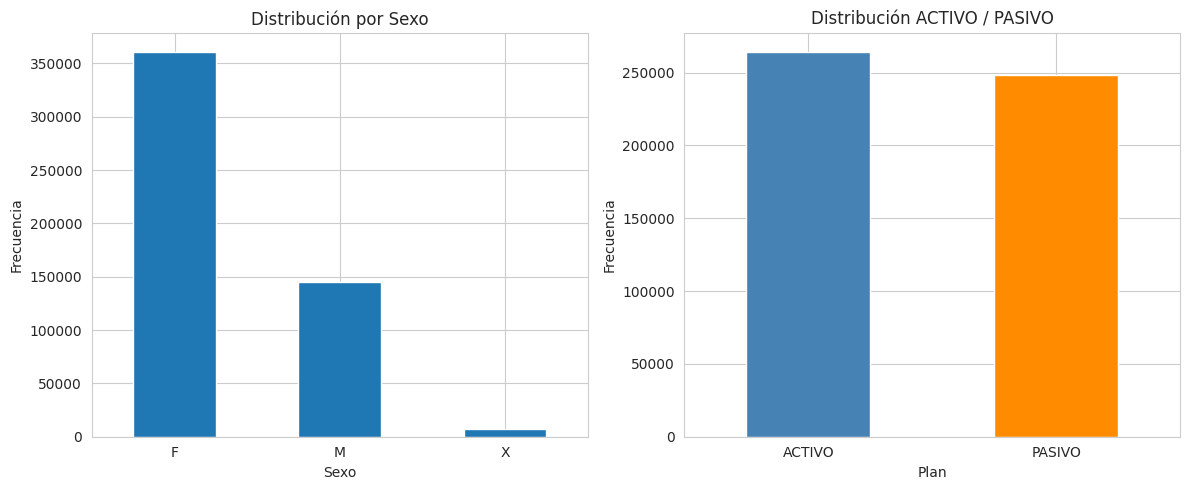

Plan
1139    51.5
1157    48.5
Name: proportion, dtype: float64 %
sexo
F    70.4
M    28.3
X     1.3
Name: proportion, dtype: float64 %


In [55]:
unique_age = df['Edad (años)'].unique()
if len(unique_age) == 1:
    print(f"La edad es constante en todos los registros: {unique_age[0]} años. No es posible generar gráficos de distribución de edad.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribución por Sexo
df['sexo'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución por Sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Distribución ACTIVO / PASIVO
plan_counts = df['Plan'].value_counts()
plan_labels = {1139: 'ACTIVO', 1157: 'PASIVO'}
# Mapear los índices numéricos a las etiquetas descriptivas
plan_counts.index = plan_counts.index.map(plan_labels)

plan_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('Distribución ACTIVO / PASIVO')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(df['Plan'].value_counts(normalize=True).round(3) * 100, '%')

print(df['sexo'].value_counts(normalize=True).round(3) * 100, '%')


Se puede observar que en el dataset existen mas afiliados del sexo femenino (70,4%) que del sexo masculino (28,3%), y que los planes de ACTIVO y PASIVO estan balanceadas.

## 6. Distribución económica (Precio, Cantidad, Cobertura)

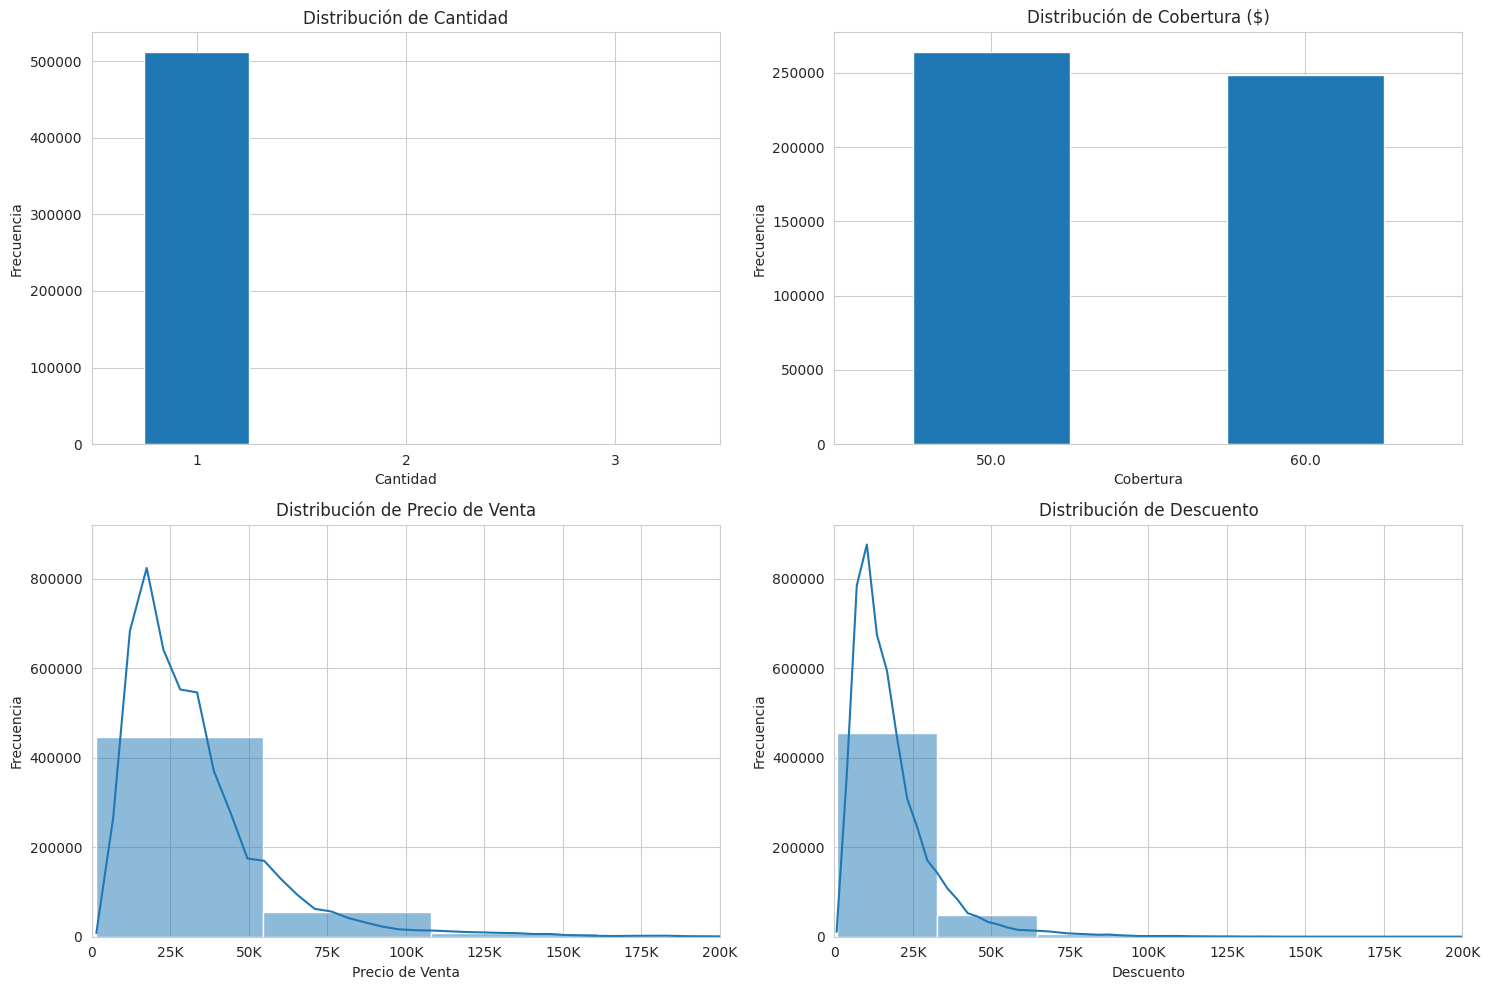

,P.Venta,Cantidad,Desc.,Cobertura
count,5.123960e+05,512396.000000,512396.000000,512396.000000
mean,3.278365e+04,1.000993,18119.360173,54.847013
std,2.598695e+04,0.038475,14693.961493,4.997664
min,1.409550e+03,1.000000,704.780000,50.000000
25%,1.703844e+04,1.000000,9164.540000,50.000000
50%,2.676514e+04,1.000000,14391.380000,50.000000
75%,4.000725e+04,1.000000,22236.320000,60.000000
max,1.065724e+06,3.000000,639434.500000,60.000000


In [56]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cantidad - Bar plot (since values are very limited)
df['Cantidad'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Cantidad')
axes[0, 0].set_xlabel('Cantidad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=0)

# Cobertura - Bar plot (since values seem limited)
df['Cobertura'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Cobertura ($)')
axes[0, 1].set_xlabel('Cobertura')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=0)

# Custom formatter function for axis labels
def custom_formatter(x, pos):
    if x >= 1_000_000:
        return f'{x*1e-6:.0f}M'
    elif x >= 1_000:
        return f'{x*1e-3:.0f}K'
    else:
        return f'{x:.0f}'

formatter = mticker.FuncFormatter(custom_formatter)

# P.Venta - Histogram with KDE
sns.histplot(df['P.Venta'], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Precio de Venta')
axes[1, 0].set_xlabel('Precio de Venta')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_xlim(0, 200000) # Set x-axis limit
axes[1, 0].xaxis.set_major_formatter(formatter) # Apply custom formatter

# Desc. - Histogram with KDE
sns.histplot(df['Desc.'], bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Descuento')
axes[1, 1].set_xlabel('Descuento')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_xlim(0, 200000) # Set x-axis limit
axes[1, 1].xaxis.set_major_formatter(formatter) # Apply custom formatter

# Calculate max y-limit for consistency across P.Venta and Desc. plots
max_y_lim = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
axes[1, 0].set_ylim(0, max_y_lim)
axes[1, 1].set_ylim(0, max_y_lim)

plt.tight_layout()
plt.show()

df[['P.Venta','Cantidad','Desc.','Cobertura']].describe()

Se observa que la gran mayoría de registros tiene un precio de venta de un poco mas de $50.000 y se reduce considerablemente el numero en los demas segmentos de precio de venta.

## 7. Matriz de correlación (variables numéricas)

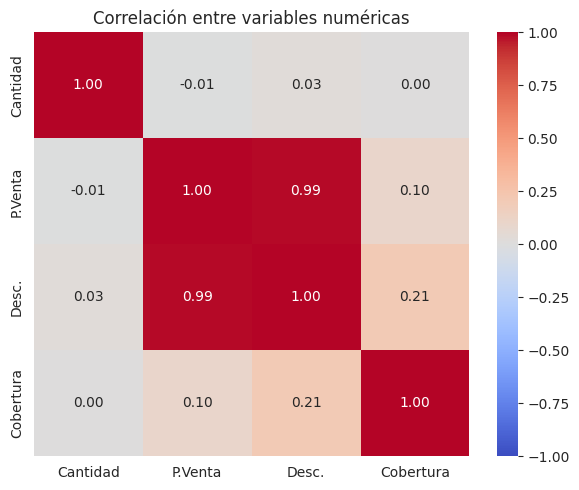

In [57]:
num_cols = ['Cantidad', 'P.Venta', 'Desc.', 'Cobertura']
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()


Se observa:
- Una fuerte correlación entre el precio de venta y el descuento.
- Una muy leve relación entre la cobertura y el precio de venta.
- Una muy leve relación entre la cobertura y el descuento.

## 8. Distribución temporal de dispensas

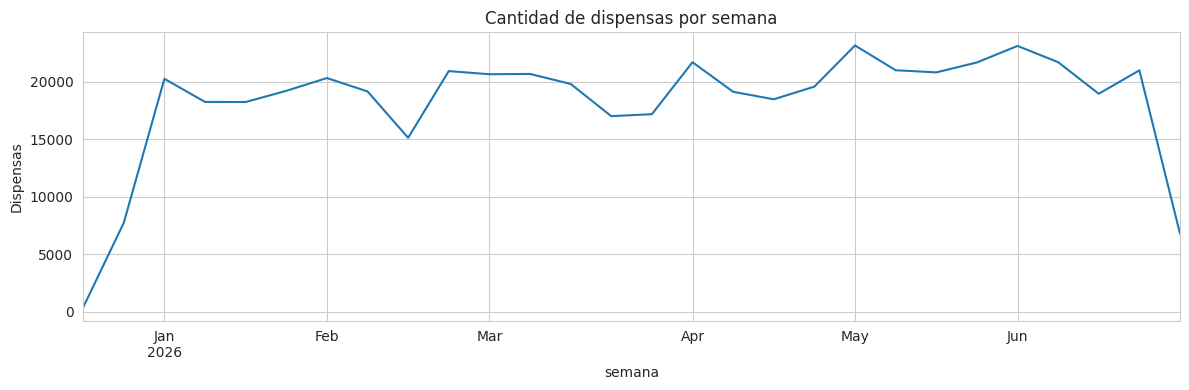

In [58]:
df['semana'] = df['F. Receta'].dt.to_period('W-SUN').dt.start_time
dispensas_por_semana = df.groupby('semana').size()

plt.figure(figsize=(12,4))
dispensas_por_semana.plot()
plt.title('Cantidad de dispensas por semana')
plt.ylabel('Dispensas')
plt.tight_layout()
plt.show()


Se puede observar que la cantidad de dispensas se mantiene estable en el periodo analizado.

## 9. Top farmacias, médicos y productos por volumen

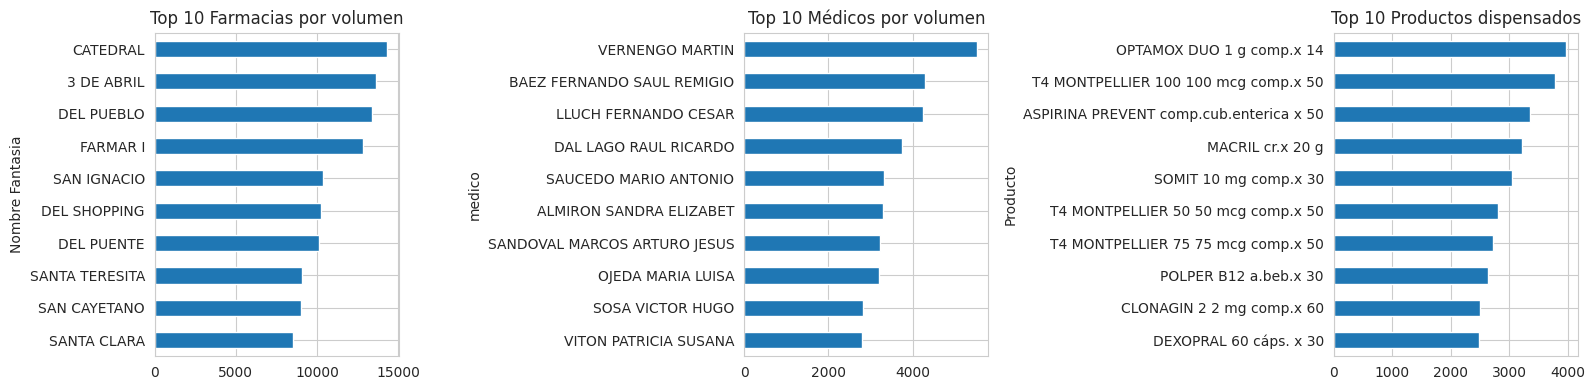

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

df['Nombre Fantasia'].value_counts().head(10).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 10 Farmacias por volumen')
axes[0].invert_yaxis()

df['medico'].value_counts().head(10).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Médicos por volumen')
axes[1].invert_yaxis()

df['Producto'].value_counts().head(10).plot(kind='barh', ax=axes[2])
axes[2].set_title('Top 10 Productos dispensados')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Top 10 Afiliados por Consumo (Enero-Junio)

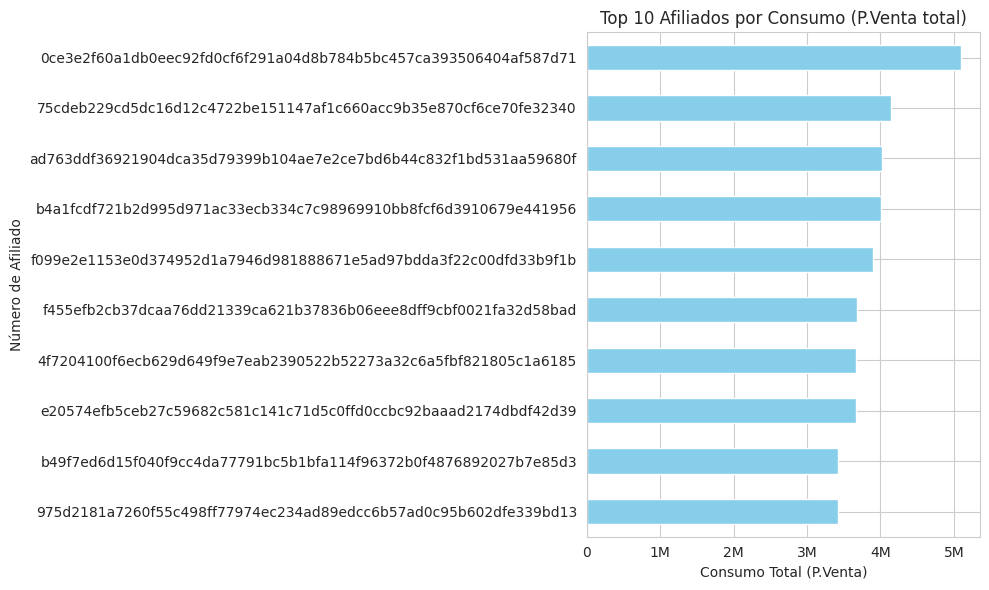

In [61]:
top_10_afiliados = df.groupby('Nro.Afil_hashed')['P.Venta'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_10_afiliados.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 10 Afiliados por Consumo (P.Venta total)')
plt.xlabel('Consumo Total (P.Venta)')
plt.ylabel('Número de Afiliado')

# Apply the custom formatter to the x-axis
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## 12. Top 10 Productos Consumidos por los 5 Afiliados con Mayor Consumo

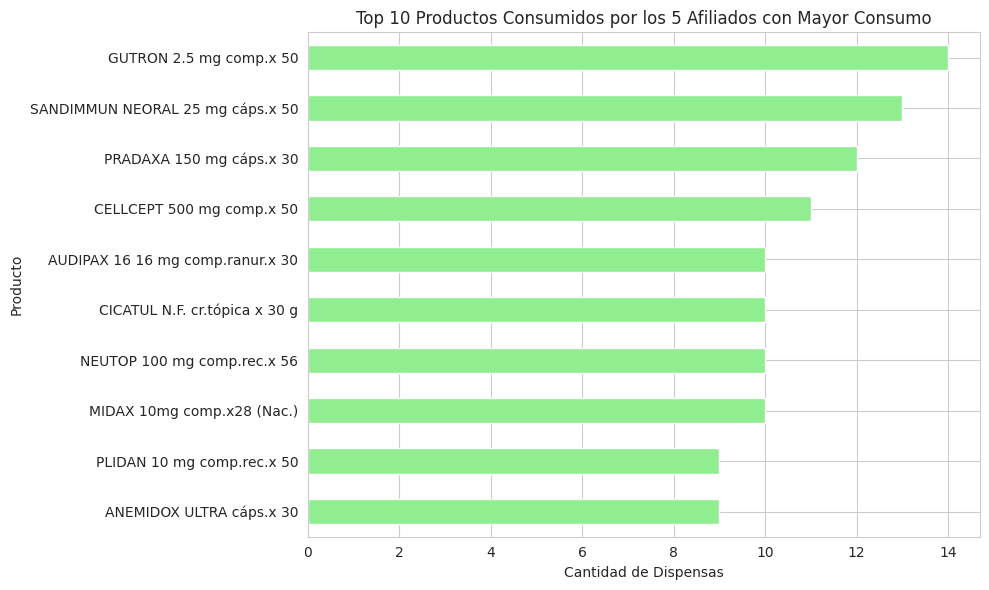

In [62]:
# Obtener los Nro.Afil_hashed de los 5 afiliados con mayor consumo
top_5_afiliado_ids = top_10_afiliados.head(5).index

# Filtrar el DataFrame para incluir solo los registros de estos 5 afiliados
df_top_5_afiliados = df[df['Nro.Afil_hashed'].isin(top_5_afiliado_ids)]

# Contar los productos más consumidos por estos 5 afiliados
top_10_productos_top_5_afiliados = df_top_5_afiliados['Producto'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
top_10_productos_top_5_afiliados.sort_values(ascending=True).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Productos Consumidos por los 5 Afiliados con Mayor Consumo')
plt.xlabel('Cantidad de Dispensas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

## 13. Detalle de Consumo Individual para los Top 5 Afiliados


--- Detalles para el Afiliado: 0ce3e2f60a1db0eec92fd0cf6f291a04d8b784b5bc457ca393506404af587d71 ---
Consumo Total (P.Venta): $5,100,531.73
Descuento Total: $3,060,319.06


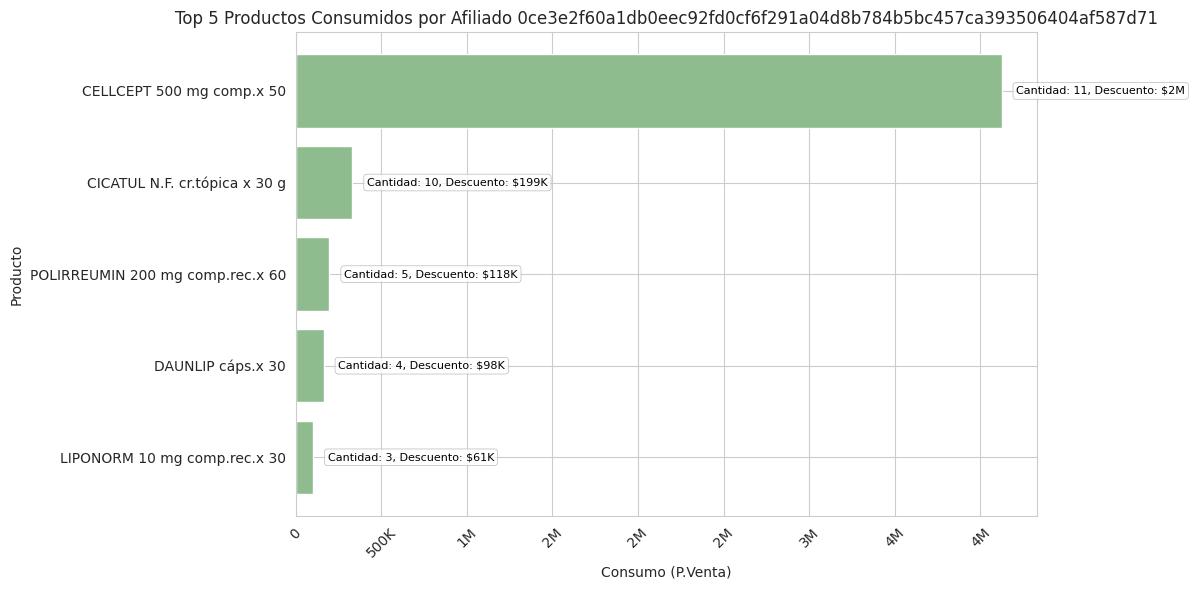


--- Detalles para el Afiliado: 75cdeb229cd5dc16d12c4722be151147af1c660acc9b35e870cf6ce70fe32340 ---
Consumo Total (P.Venta): $4,142,618.67
Descuento Total: $2,485,571.17


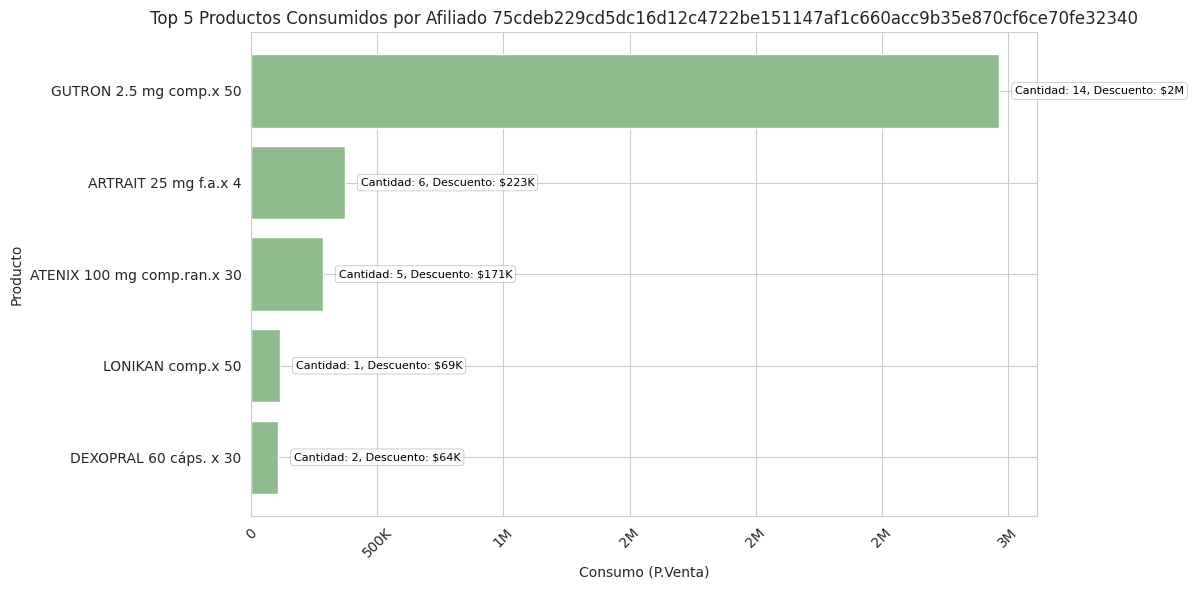


--- Detalles para el Afiliado: ad763ddf36921904dca35d79399b104ae7e2ce7bd6b44c832f1bd531aa59680f ---
Consumo Total (P.Venta): $4,020,967.40
Descuento Total: $2,412,580.43


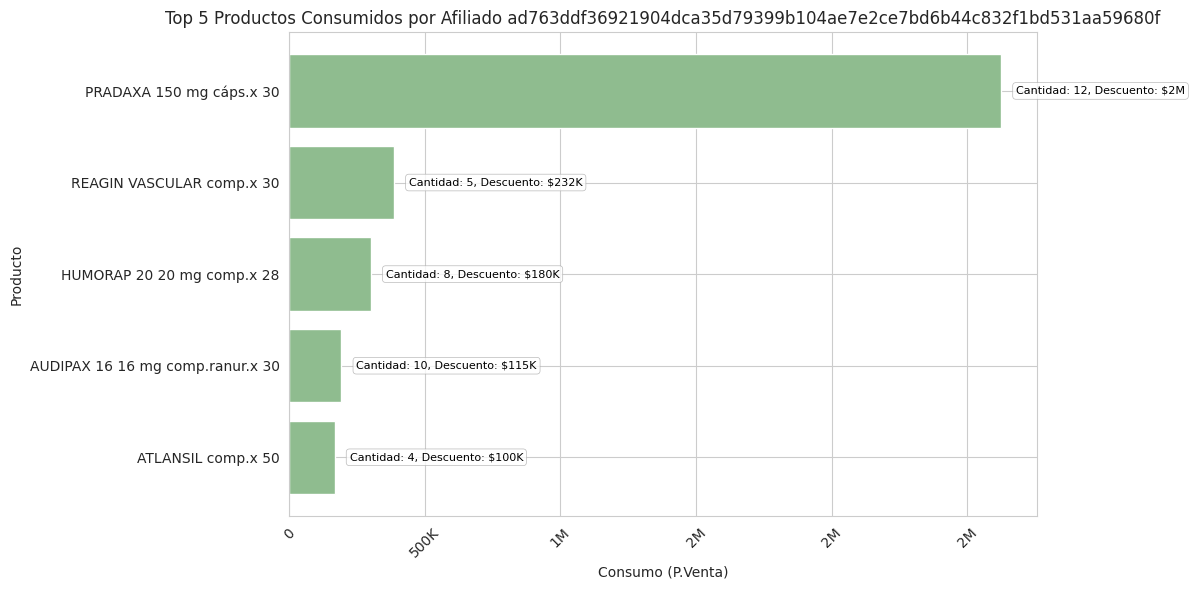


--- Detalles para el Afiliado: b4a1fcdf721b2d995d971ac33ecb334c7c98969910bb8fcf6d3910679e441956 ---
Consumo Total (P.Venta): $4,014,431.28
Descuento Total: $2,007,215.73


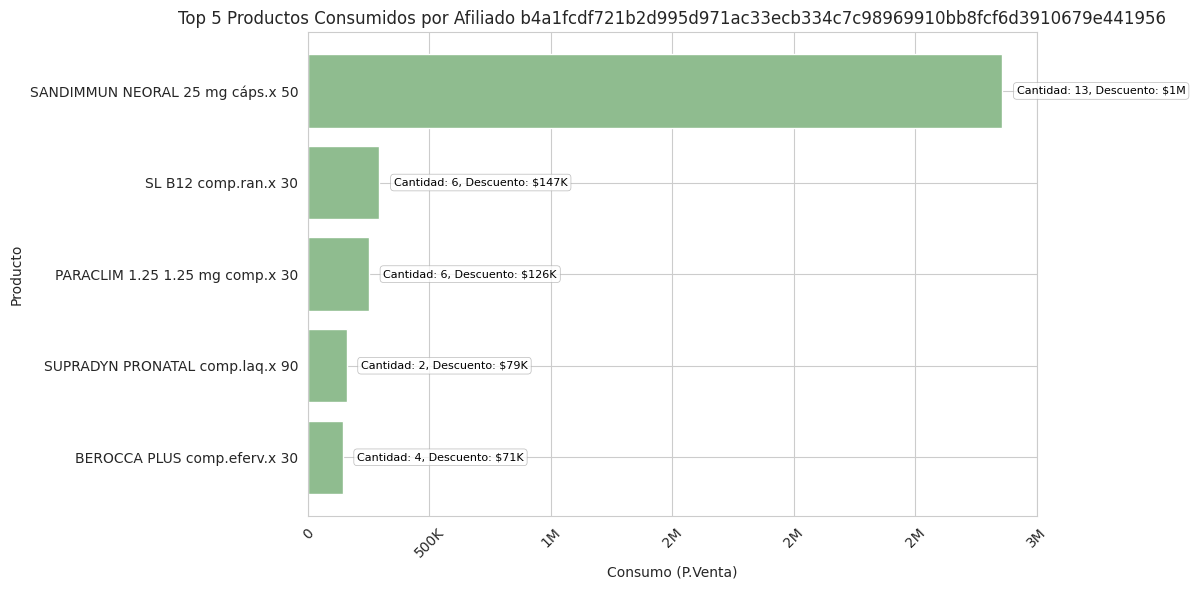


--- Detalles para el Afiliado: f099e2e1153e0d374952d1a7946d981888671e5ad97bdda3f22c00dfd33b9f1b ---
Consumo Total (P.Venta): $3,901,952.57
Descuento Total: $2,341,171.53


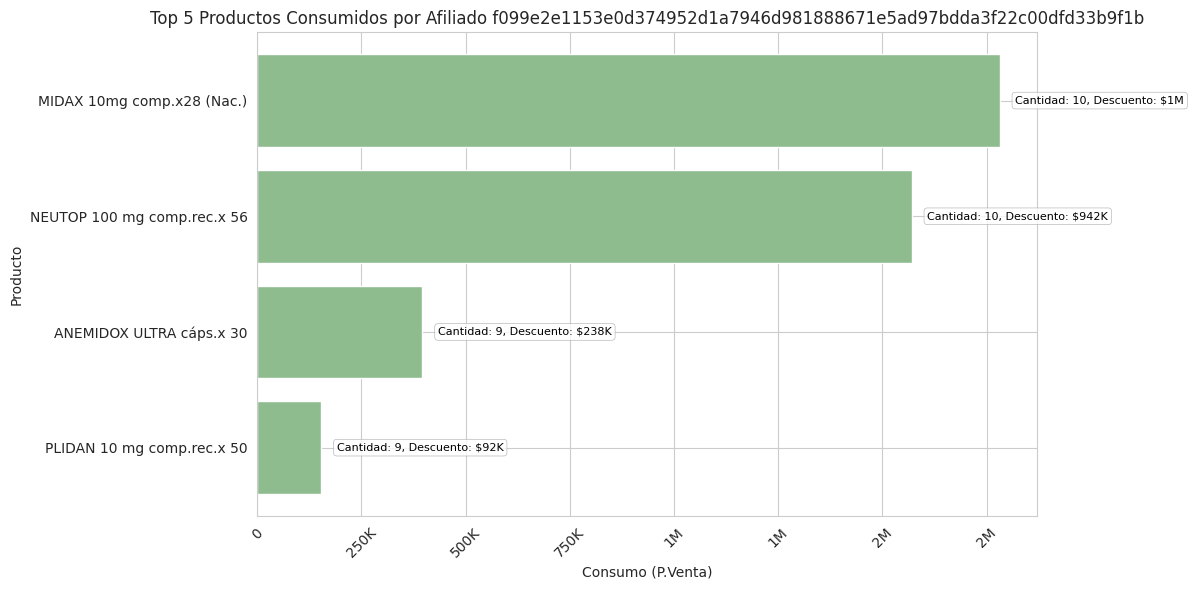

In [63]:
for afiliado_id in top_5_afiliado_ids:
    # Filtrar datos para el afiliado actual
    df_afiliado = df[df['Nro.Afil_hashed'] == afiliado_id]

    # Calcular el consumo total del afiliado
    consumo_total_afiliado = df_afiliado['P.Venta'].sum()
    # Calcular el descuento total del afiliado
    descuento_total_afiliado = df_afiliado['Desc.'].sum()

    print(f"\n--- Detalles para el Afiliado: {afiliado_id} ---")
    print(f"Consumo Total (P.Venta): ${consumo_total_afiliado:,.2f}")
    print(f"Descuento Total: ${descuento_total_afiliado:,.2f}")

    # Agrupar por producto y sumar P.Venta, Cantidad y Desc.
    product_summary = df_afiliado.groupby('Producto').agg(
        Total_P_Venta=('P.Venta', 'sum'),
        Total_Cantidad=('Cantidad', 'sum'),
        Total_Desc=('Desc.', 'sum')
    )
    # Seleccionar los top 5 productos basándose en Total_P_Venta y ordenar para la gráfica
    top_products_afiliado_detail = product_summary.nlargest(5, 'Total_P_Venta').sort_values(by='Total_P_Venta', ascending=True)

    if not top_products_afiliado_detail.empty:
        fig, ax = plt.subplots(figsize=(12, 6)) # Aumentar tamaño para las anotaciones

        # Graficar barras para el Total_P_Venta
        bars = ax.barh(top_products_afiliado_detail.index, top_products_afiliado_detail['Total_P_Venta'], color='darkseagreen')

        ax.set_title(f'Top 5 Productos Consumidos por Afiliado {afiliado_id}')
        ax.set_xlabel('Consumo (P.Venta)')
        ax.set_ylabel('Producto')
        ax.xaxis.set_major_formatter(formatter) # Aplicar el formateador personalizado al eje x
        ax.tick_params(axis='x', rotation=45) # Rotar etiquetas del eje x si se superponen

        # Añadir anotaciones a cada barra
        for i, bar in enumerate(bars):
            product_name = top_products_afiliado_detail.index[i]
            total_p_venta = top_products_afiliado_detail.loc[product_name, 'Total_P_Venta']
            total_cantidad = int(top_products_afiliado_detail.loc[product_name, 'Total_Cantidad'])
            total_desc = top_products_afiliado_detail.loc[product_name, 'Total_Desc']

            # Formatear valores de descuento
            desc_formatted = formatter(total_desc, None)

            # Texto de la anotación
            annotation_text = f"Cantidad: {total_cantidad}, Descuento: ${desc_formatted}"

            # Posicionar la anotación ligeramente a la derecha del final de la barra
            ax.text(total_p_venta + (ax.get_xlim()[1] * 0.02), bar.get_y() + bar.get_height()/2,
                    annotation_text,
                    va='center', ha='left', fontsize=8, color='black',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkgray", lw=0.5, alpha=0.8))

        plt.tight_layout()
        plt.show()
    else:
        print("No hay productos registrados para este afiliado.")

## 14. Gráfico de dispersión de consumo de afiliado (Enero - Junio)

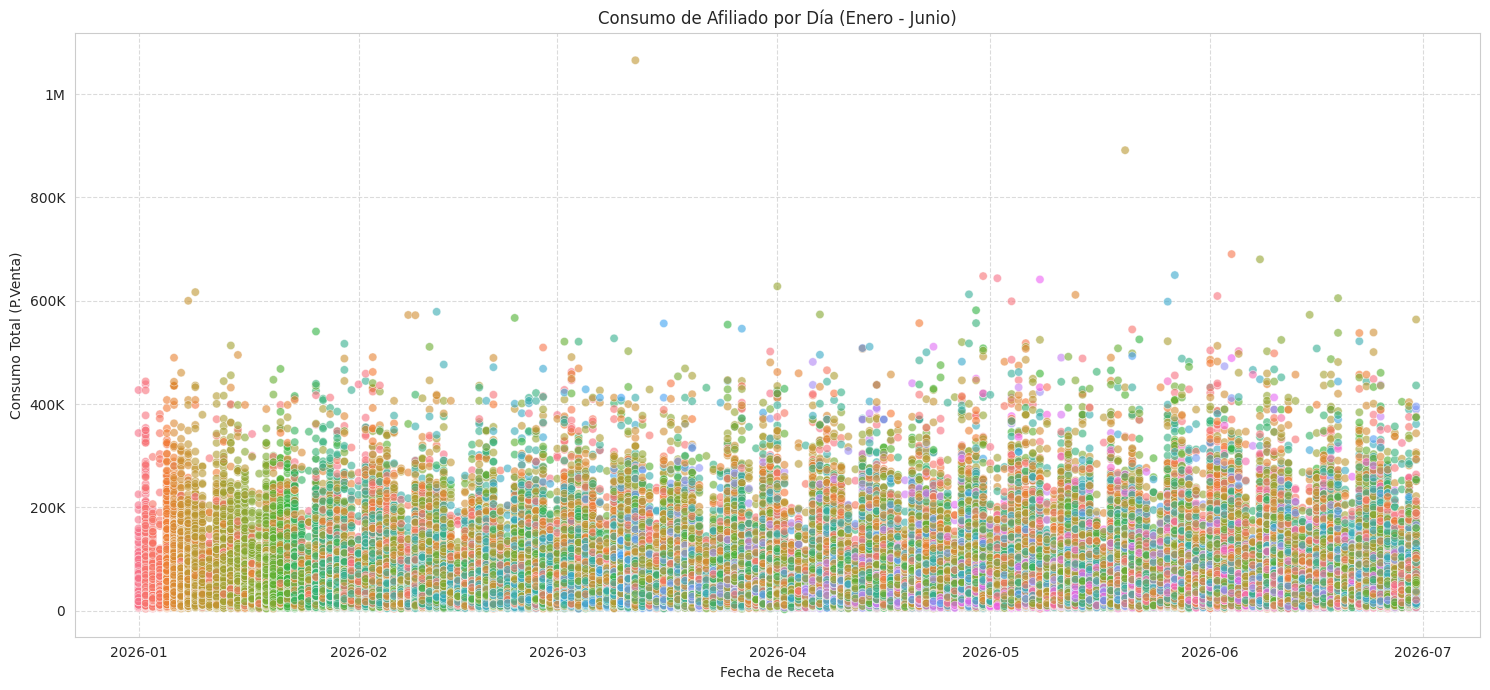

In [64]:
# Filtrar los datos para el rango de fechas de Enero a Junio
df_filtered_months = df[(df['F. Receta'].dt.month >= 1) & (df['F. Receta'].dt.month <= 6)]

# Calcular el consumo total (P.Venta) por afiliado y por día
consumo_diario_afiliado = df_filtered_months.groupby(['F. Receta', 'Nro.Afil_hashed'])['P.Venta'].sum().reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(15, 7))
sns.scatterplot(data=consumo_diario_afiliado, x='F. Receta', y='P.Venta', alpha=0.6, hue='Nro.Afil_hashed', legend=False)

plt.title('Consumo de Afiliado por Día (Enero - Junio)')
plt.xlabel('Fecha de Receta')
plt.ylabel('Consumo Total (P.Venta)')
plt.grid(True, linestyle='--', alpha=0.7)

# Aplicar el formateador personalizado al eje y
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

En este gráfico se puede observar que la gran mayoria de los consumos de los afiliados no superan los $400.000 mensuales.

## 16. Consumo individual para Afiliados con Consumo Total > 500K (Enero - Junio)

In [65]:
# Filtrar las transacciones individuales con P.Venta superior a 500.000
outlier_transactions = df_filtered_months[df_filtered_months['P.Venta'] > 500000]

if not outlier_transactions.empty:
    print("Detalle de transacciones individuales con 'P.Venta' superior a $500.000")
    display(outlier_transactions)
else:
    print("No se encontraron transacciones individuales con 'P.Venta' superior a $500.000 en este subconjunto de datos.")

Detalle de transacciones individuales con 'P.Venta' superior a $500.000


,CUIT,Razon Social,Nombre Fantasia,calle_nombre,calle_altura,localidad_nombre,Provincia,F.Validac.,Nro. Receta,Nro.item,sexo,Edad (años),Producto,Cantidad,P.Venta,Desc.,Cod.Valid.,Estado,F. Receta,p.Activo,Cobertura,Plan,T.mat,nro.mat.,medico,registroab,troquel,codigobarra,nrodoc,Ctro Costo,Laboratorio,Labo_Id,Prestador,Presentacion fcia,ID externo,Recetario Orig,semana,CUF_hashed,Nro.Afil_hashed,Afiliado_hashed
17715,30688012453,FARMACIA MENDOZA S C S,MENDOZA,FRAY J DE LA QUINTANA,1301,CORRIENTES,CORRIENTES,2026-04-14 11:13:08.590416,2610465112690,1,M,55.0,NEUTROMAX 30 MUI (300 mcg) f.a.x 5,1,510994.55,255497.28,2610451169344,Receta Presentada en un lote por la farmacia,2026-04-14,filgrastim,50.0,1139,MPW,5127.0,POMARES Damian,16597,4001853,7.795355e+12,11733487,NaN,Biosidus S.A.U.,858,NaN,105239003425417509,0,2610465112690,2026-04-13,61ba0e142c331d50e8a1afdc469699c5f7fab9eb211a0b...,92b220b8c95d31a15a716118a92cb9a5fa5ab905b6b91d...,8f59bb8005968b1453699fd7250690986985c8aab7b0f2...
31109,23257435644,NUÑEZ GRISEL SARA,ACTIVA,JUAN ROMERO,846,SAN LUIS DEL PALMAR,CORRIENTES,2026-04-23 12:47:27.771269,2611366240894,1,M,55.0,NEUTROMAX 30 MUI (300 mcg) f.a.x 5,1,510994.55,255497.28,2611352089713,Receta Presentada en un lote por la farmacia,2026-04-23,filgrastim,50.0,1139,MPW,4992.0,ROMERO ELSA BEATRIZ,16597,4001853,7.795355e+12,37427412,NaN,Biosidus S.A.U.,858,NaN,105239401715410128,0,2611366240894,2026-04-20,93eb05f61effe524a0bae6103936f85dab41667a1fd173...,753321e23d46559a372bc52b5d89771587355dfc19de84...,4b108d1edc9b7483634395f0f87795d6e62032cf77163f...
82819,30596388074,FARMACIA SALTA SCS,SALTA,SALTA,1598,CORRIENTES,CORRIENTES,2026-04-30 10:14:31.991057,2612067000663,1,F,55.0,5-ASA 4000 4 g sob.x 30,1,592494.51,355496.71,2612052724312,Receta Presentada en un lote por la farmacia,2026-04-30,mesalazina,60.0,1157,MPW,1465.0,DELFINO MARIA INES ENRIQUETA,59115,6655681,7.795327e+12,11719038,NaN,Domínguez,67,NaN,105257003155475527,0,2612067000663,2026-04-27,c00a93eb0dec6af8b08937ecefba31408458dd2d51f9ba...,ae90a7b687d8869f61d086d8f3aa20ca106ea66be1c823...,603c020e9b62ad90709b71e0158c23436d990cd01b717f...
195368,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-06-12 11:43:41.749855,2615671420412,1,M,55.0,HEXAXIM jga.prell.x 0.5ml,1,502564.00,251282.00,2616357289553,Receta Presentada en un lote por la farmacia,2026-06-05,dtap+ipv+hep.b+hib,50.0,1139,MPW,4714.0,CACERES COLLANTES Eduardo Federico,50463,6259841,7.798016e+12,70912713,NaN,Sanofi Health A,153,NaN,105239003145623775,0,2615671420412,2026-06-01,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,3318aab4882a30a28de0f7865a21fe6eaf4dd70c720068...,8fb2db28fd2c6ed0fa4510370f0fa6f31b17586f0f1edc...
248721,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-06-17 15:43:50.035226,2616772484142,1,M,55.0,RISPERDAL CONSTA 37.5 mg vial a.x 1+aguja,1,507545.36,304527.22,2616857697208,Receta Presentada en un lote por la farmacia,2026-06-16,risperidona,60.0,1157,MPW,4449.0,RODRIGUEZ JONAS ELIZALDO,52461,5111222,7.795314e+12,16357729,NaN,Janssen-Cilag,127,NaN,105257003145623793,0,2616772484142,2026-06-15,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,132caa98b4af0c987f0a9bc529bd351e3f45da43b55b26...,eee90afb372251319ab537edd1e451b552400956a3ef47...
489057,30643249312,FARMACIA 3 DE ABRIL SCS,3 DE ABRIL,MENDOZA,1598,CORRIENTES,CORRIENTES,2026-03-13 18:41:08.157961,c51430,1,M,55.0,CLEXANE 80 mg jga.prell.x 10,1,1065724.16,639434.50,2607248334823,Receta Presentada en un lote por la farmacia,2026-03-12,enoxaparina sódica,60.0,1157,MN,3810.0,ROMERO MACIEL MARIA DE LOS ANG,18694,4208602,7.795312e+12,4367246,NaN,Sanofi-Aventis,703,NaN,105246003225300521,0,51430,2026-03-09,d769a280d3975662acfda60b3627eeced74d03f515aa5c...,579aca8f53bde2024de9891fc9ba18136bc79378546366...,dcd75fbf90304d9bbea6ba94be62334d44e759a3f7d111...


## Conclusiones del EDA
*(completar con las observaciones concretas una vez corrido sobre el dataset real, para incluir en la sección Resultados del informe)*